In [1]:
# 1. 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_linnerud
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# 2. 데이터 로드
linnerud = load_linnerud()
X = pd.DataFrame(linnerud.data, columns=linnerud.feature_names)
y = pd.DataFrame(linnerud.target, columns=linnerud.target_names)

print("입력 데이터(X) shape:", X.shape)
print("타겟 데이터(y) shape:", y.shape)


입력 데이터(X) shape: (20, 3)
타겟 데이터(y) shape: (20, 3)


In [3]:
# 3. 데이터 미리보기
display(X.head())
display(y.head())


,Chins,Situps,Jumps
0,5.0,162.0,60.0
1,2.0,110.0,60.0
2,12.0,101.0,101.0
3,12.0,105.0,37.0
4,13.0,155.0,58.0


,Weight,Waist,Pulse
0,191.0,36.0,50.0
1,189.0,37.0,52.0
2,193.0,38.0,58.0
3,162.0,35.0,62.0
4,189.0,35.0,46.0


In [4]:
# 4. 기초 통계 정보
print("\n=== X 데이터 정보 ===")
display(X.describe())
print("\n=== y 데이터 정보 ===")
display(y.describe())



=== X 데이터 정보 ===


,Chins,Situps,Jumps
count,20.000000,20.000000,20.00000
mean,9.450000,145.550000,70.30000
std,5.286278,62.566575,51.27747
min,1.000000,50.000000,25.00000
25%,4.750000,101.000000,39.50000
50%,11.500000,122.500000,54.00000
75%,13.250000,210.000000,85.25000
max,17.000000,251.000000,250.00000



=== y 데이터 정보 ===


,Weight,Waist,Pulse
count,20.000000,20.000000,20.000000
mean,178.600000,35.400000,56.100000
std,24.690505,3.201973,7.210373
min,138.000000,31.000000,46.000000
25%,160.750000,33.000000,51.500000
50%,176.000000,35.000000,55.000000
75%,191.500000,37.000000,60.500000
max,247.000000,46.000000,74.000000


In [5]:
# 5. 결측치 확인
print("X 결측치:\n", X.isnull().sum())
print("y 결측치:\n", y.isnull().sum())

X 결측치:
 Chins     0
Situps    0
Jumps     0
dtype: int64
y 결측치:
 Weight    0
Waist     0
Pulse     0
dtype: int64


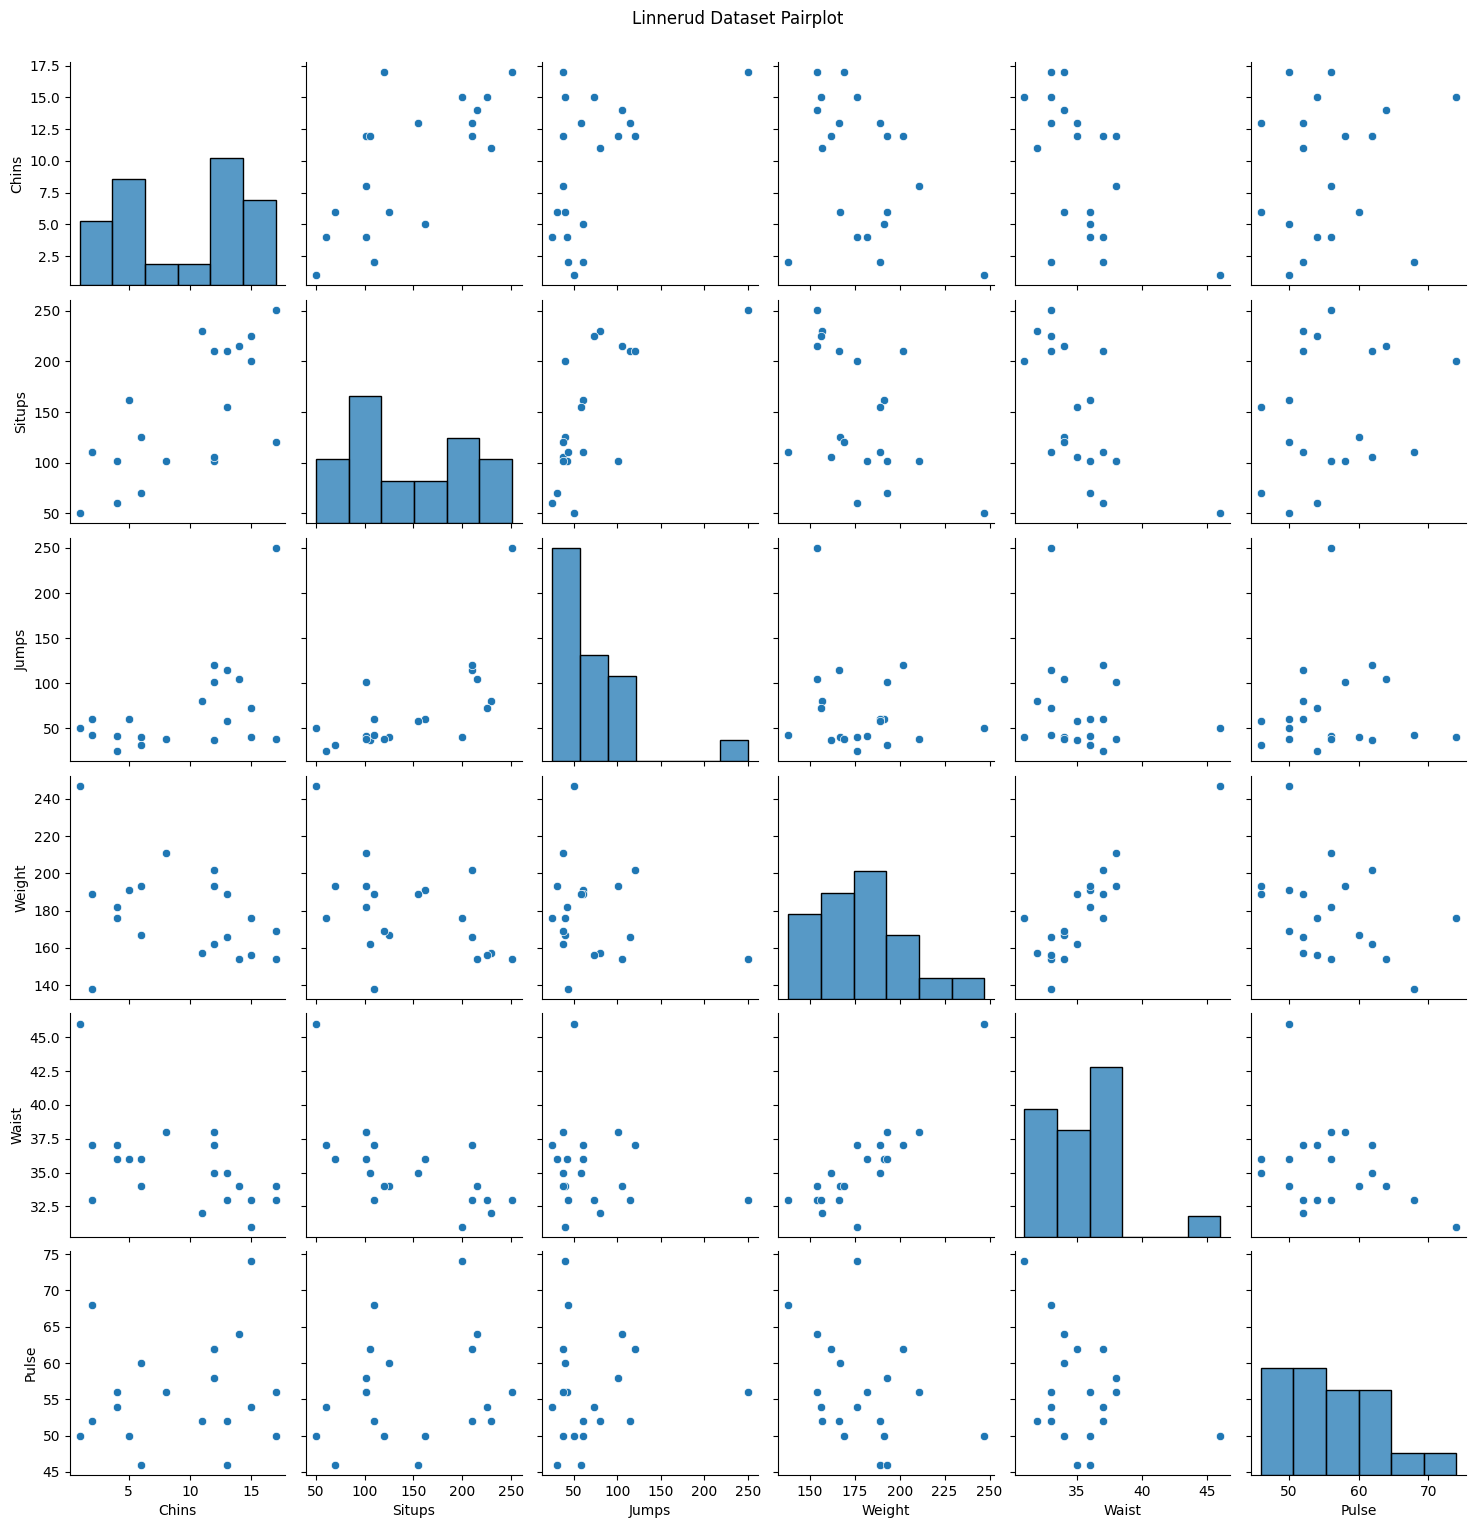

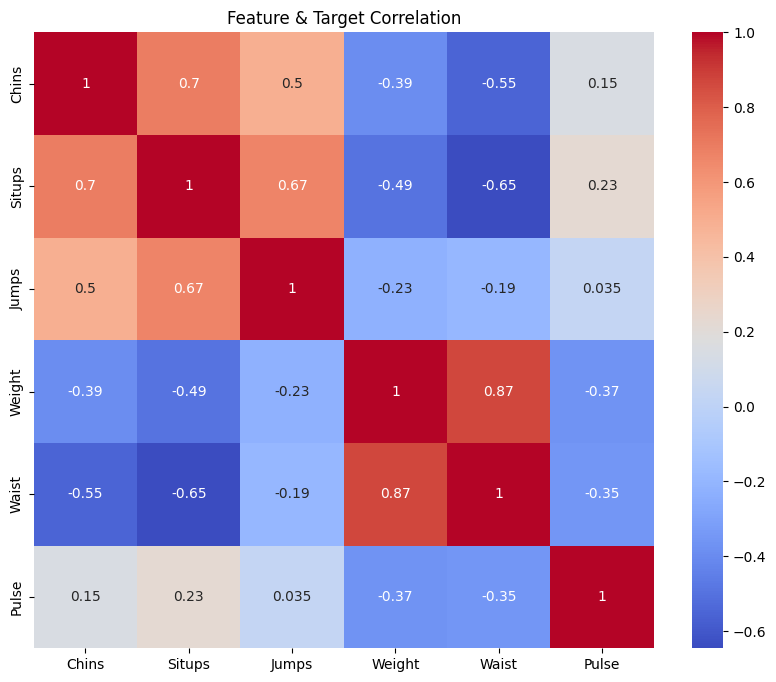

In [6]:
# 6. EDA - 산점도 행렬
sns.pairplot(pd.concat([X, y], axis=1))
plt.suptitle("Linnerud Dataset Pairplot", y=1.02)
plt.show()

# 7. 상관계수 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(pd.concat([X, y], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature & Target Correlation")
plt.show()



In [7]:
# 8. 회귀 모델 학습 (예: Weight 예측)
target_col = "Weight"
X_train = X
y_train = y[target_col]

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# 9. 예측
y_pred = model.predict(X_train)

In [9]:
# 10. 평가
mse = mean_squared_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)
print(f"{target_col} 예측 MSE: {mse:.2f}")
print(f"{target_col} 예측 R²: {r2:.2f}")


Weight 예측 MSE: 423.98
Weight 예측 R²: 0.27


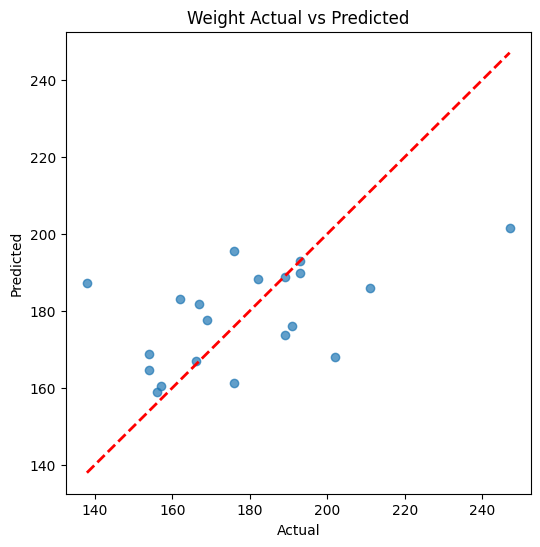

In [10]:
# 11. 실제값 vs 예측값 시각화
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_pred, alpha=0.7)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"{target_col} Actual vs Predicted")
plt.show()